# **프로젝트: mini BERT 만들기**

vocab_size=8000, 전체 파라미터 ~1M의 경량 BERT 모델 사전학습

<br><br/>
*본 파일은 26/03/16 코드 리뷰 후 수정한 버전임

## 1. 라이브러리 불러오기 &  환경 확인

In [1]:
# 라이브러리 불러오기
from __future__ import absolute_import, division, print_function, unicode_literals
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.functional import cosine_similarity
 
import os
import shutil
import re
import math
import numpy as np
import pandas as pd
import random
import copy
import json
 
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import sentencepiece as spm
from tqdm.notebook import tqdm
import logging

# 한글 폰트 설정
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()
 
# 버전 확인
print("torch    :", torch.__version__)
print("numpy    :", np.__version__)
print("pandas   :", pd.__version__)

torch    : 2.7.1+cu118
numpy    : 2.2.6
pandas   : 2.3.0


In [2]:
def set_seed(seed=42):
    """재현성을 위해 모든 난수 시드를 고정"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) # 시드 고정

In [3]:
# GPU / CPU 환경 확인
print("=" * 50)
print("Device 정보")
print("=" * 50)
 
if torch.cuda.is_available():
    device = torch.device("cuda")
    n_gpus = torch.cuda.device_count()
    print(f"사용 가능한 GPU 수: {n_gpus}")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        total_vram = props.total_memory / (1024 ** 3)  # GB 단위
        print(f"  GPU {i}: {props.name}")
        print(f"    VRAM: {total_vram:.2f} GB")
        print(f"    CUDA Capability: {props.major}.{props.minor}")
        print(f"    SM 수: {props.multi_processor_count}")
    # 현재 사용 중인 GPU 메모리 상태
    allocated = torch.cuda.memory_allocated(0) / (1024 ** 3)
    reserved  = torch.cuda.memory_reserved(0)  / (1024 ** 3)
    print(f"\n현재 GPU 메모리 사용: {allocated:.2f} GB (allocated) / {reserved:.2f} GB (reserved)")
else:
    device = torch.device("cpu")
    print("GPU 없음 — CPU로 실행")
 
print(f"\n학습에 사용할 device: {device}")
print("=" * 50)

Device 정보
사용 가능한 GPU 수: 1
  GPU 0: Tesla T4
    VRAM: 14.58 GB
    CUDA Capability: 7.5
    SM 수: 40

현재 GPU 메모리 사용: 0.00 GB (allocated) / 0.00 GB (reserved)

학습에 사용할 device: cuda


## 2. Tokenizer 준비

`vocab_size=8000` 센텐스피스 모델을 불러와 사용한다.

In [4]:
# 이미 학습된 sentencepiece 모델 로드
model_dir = './models'
vocab_model_path = f'{model_dir}/ko_8000.model'
 
vocab = spm.SentencePieceProcessor()
vocab.load(vocab_model_path)
 
print(f"vocab 로드 완료: {vocab_model_path}")
print(f"vocab size: {len(vocab)}")

vocab 로드 완료: ./models/ko_8000.model
vocab size: 8007


In [5]:
# 특수 토큰 7개를 제외한 일반 토큰 목록 생성
# BERT에 필요한 특수 토큰: [PAD]=0, [UNK]=1, [CLS]=2(혹은 별도), [SEP], [MASK] 등
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
 
print(f"일반 토큰 수 (특수 7개 제외): {len(vocab_list)}")
print("앞 10개 토큰 샘플:", vocab_list[:10])
print("뒤 10개 토큰 샘플:", vocab_list[-10:])

일반 토큰 수 (특수 7개 제외): 8000
앞 10개 토큰 샘플: ['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다']
뒤 10개 토큰 샘플: ['竇', '虜', '鄴', '겊', '꽌', '垈', '尸', '慚', '楠', '絹']


In [6]:
# 토크나이저 동작 확인
sample = "안녕하세요. 미니 BERT 사전학습을 시작합니다."
tokens = vocab.encode_as_pieces(sample)
ids    = vocab.encode_as_ids(sample)
 
print("원문  :", sample)
print("토큰  :", tokens)
print("ID    :", ids)
print("복원  :", vocab.decode_pieces(tokens))

원문  : 안녕하세요. 미니 BERT 사전학습을 시작합니다.
토큰  : ['▁안', '녕', '하', '세', '요', '.', '▁미', '니', '▁B', 'E', 'R', 'T', '▁사', '전', '학', '습', '을', '▁시작', '합', '니다', '.']
ID    : [172, 4530, 3605, 3692, 3769, 3599, 55, 3733, 395, 3899, 3924, 3839, 15, 3640, 3685, 4005, 3607, 253, 3814, 1201, 3599]
복원  : 안녕하세요. 미니 BERT 사전학습을 시작합니다.


## 3. 데이터 전처리

### 3-1. 문장 길이 분포 시각화 및 max_seq_len 결정

전체 문장의 90~95%가 포함되는 길이를 확인해 `n_seq`를 결정한다.

In [7]:
# 코퍼스 경로
corpus_file = './data/kowiki.txt'
 
# 문장 길이 분포 샘플링 (전체가 너무 크면 일부만 샘플링)
SAMPLE_LIMIT = 500_000  # 50만 문장 샘플 / 전체 행 수는 3960k개
 
lengths = []
with open(corpus_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_LIMIT:
            break
        line = line.strip()
        if line:
            pieces = vocab.encode_as_pieces(line)
            if len(pieces) > 0:
                lengths.append(len(pieces))
 
lengths = np.array(lengths)
print(f"샘플 문장 수: {len(lengths):,}")
print(f"평균 길이   : {lengths.mean():.1f}")
print(f"최대 길이   : {lengths.max()}")
print(f"최소 길이   : {lengths.min()}")
print()
for pct in [50, 75, 85, 90, 95, 99]:
    print(f"  {pct}th percentile: {np.percentile(lengths, pct):.0f} tokens")

샘플 문장 수: 375,047
평균 길이   : 87.6
최대 길이   : 4780
최소 길이   : 1

  50th percentile: 68 tokens
  75th percentile: 125 tokens
  85th percentile: 162 tokens
  90th percentile: 191 tokens
  95th percentile: 242 tokens
  99th percentile: 371 tokens


In [8]:
# 샘플 하나 추출해서 토크나이징 결과 확인
sample_idx  = random.randint(0, len(lengths) - 1)

# lengths 배열과 같은 순서로 읽은 실제 문장 추출
sample_line = ""
line_count  = 0
with open(corpus_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            if line_count == sample_idx:
                sample_line = line
                break
            line_count += 1

sample_pieces = vocab.encode_as_pieces(sample_line)
sample_ids    = vocab.encode_as_ids(sample_line)

print(f"샘플 인덱스  : {sample_idx}")
print(f"원문         : {sample_line}")
print(f"토큰 수      : {len(sample_pieces)}")
print(f"토큰         : {sample_pieces}")
print(f"ID           : {sample_ids}")

샘플 인덱스  : 335243
원문         : 신장은 167cm이고 체중은 49kg인 그녀는 현재 슈투트가르트 발레단의 수석 발레리나이며, 독일의 무형문화재로 등재되어 있기도 하다. 2013년 대한민국 국립발레단의 신임 단장에 내정되어 2014년 2월부터 임기를 시작했다.
토큰 수      : 65
토큰         : ['▁신', '장은', '▁16', '7', 'cm', '이고', '▁체', '중', '은', '▁4', '9', 'k', 'g', '인', '▁그녀는', '▁현재', '▁슈', '투', '트가', '르트', '▁발', '레', '단의', '▁수', '석', '▁발', '레', '리', '나', '이며', ',', '▁독일의', '▁무', '형', '문화재', '로', '▁등', '재', '되어', '▁있', '기도', '▁하다', '.', '▁2013', '년', '▁대한민국', '▁국립', '발', '레', '단의', '▁신', '임', '▁단', '장에', '▁내', '정', '되어', '▁2014', '년', '▁2', '월부터', '▁임', '기를', '▁시작했다', '.']
ID           : [90, 973, 359, 3682, 1666, 458, 336, 3678, 3613, 85, 3632, 3891, 3874, 3628, 1587, 294, 862, 3852, 2128, 1167, 67, 3740, 1346, 19, 3879, 67, 3740, 3622, 3637, 211, 3604, 2091, 107, 3780, 2530, 3603, 50, 3729, 100, 11, 255, 1684, 3599, 844, 3625, 410, 1813, 3720, 3740, 1346, 90, 3773, 164, 1312, 114, 3642, 100, 816, 3625, 12, 1996, 273, 333, 1257, 3599]


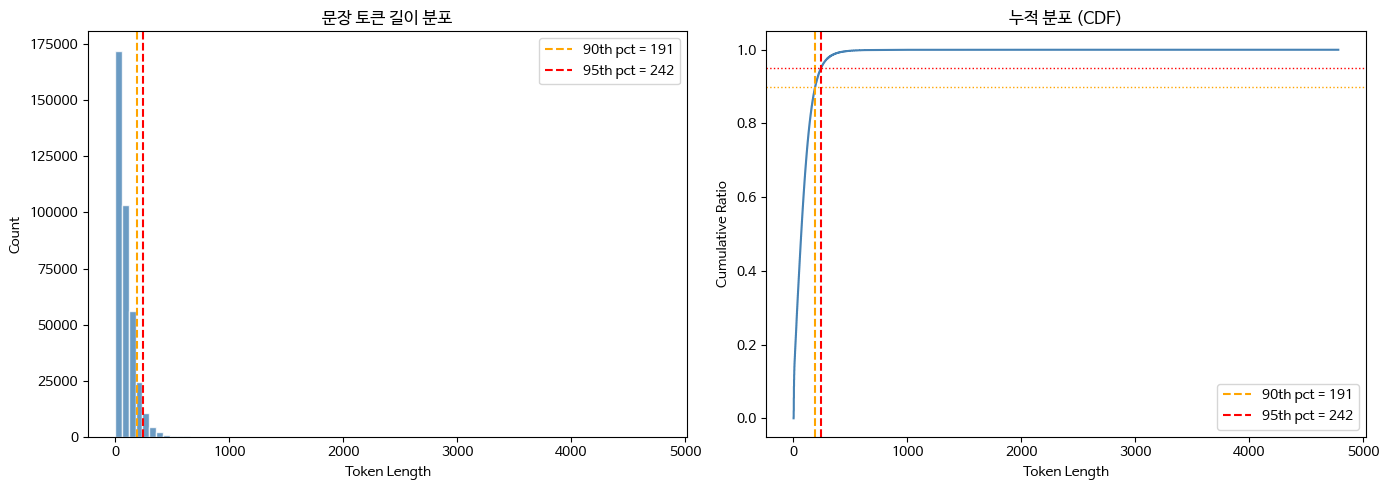


[CLS] + sent_a + [SEP] + sent_b + [SEP] 고려 시:
  90th pct 기준 → 194 (+3 for special tokens)
  95th pct 기준 → 245


In [9]:
# 길이 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# 왼쪽: 히스토그램
axes[0].hist(lengths, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
for pct, color in [(90, 'orange'), (95, 'red')]:
    val = np.percentile(lengths, pct)
    axes[0].axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{pct}th pct = {val:.0f}')
axes[0].set_xlabel('Token Length')
axes[0].set_ylabel('Count')
axes[0].set_title('문장 토큰 길이 분포')
axes[0].legend()
 
# 오른쪽: 누적 분포 (CDF)
sorted_len = np.sort(lengths)
cdf = np.arange(1, len(sorted_len) + 1) / len(sorted_len)
axes[1].plot(sorted_len, cdf, color='steelblue')
for pct, color in [(90, 'orange'), (95, 'red')]:
    val = np.percentile(lengths, pct)
    axes[1].axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{pct}th pct = {val:.0f}')
    axes[1].axhline(pct / 100, color=color, linestyle=':', linewidth=1)
axes[1].set_xlabel('Token Length')
axes[1].set_ylabel('Cumulative Ratio')
axes[1].set_title('누적 분포 (CDF)')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('./token_length_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
 
p90 = int(np.percentile(lengths, 90))
p95 = int(np.percentile(lengths, 95))
print(f"\n[CLS] + sent_a + [SEP] + sent_b + [SEP] 고려 시:")
print(f"  90th pct 기준 → {p90 + 3} (+3 for special tokens)")
print(f"  95th pct 기준 → {p95 + 3}")

50 토큰 이하의 아주 짧은 문장이 압도적으로 많고 (히스토그램 첫 번째 막대), 그 다음 그 다음 100~200토큰 구간이 두 번째로 많다 (두 번째 막대).  

데이터셋 특성상 제목, 소제목, 단문 설명 같은 짧은 행이 엄청나게 많고, 본문 서술 문장이 그 뒤를 따르는 패턴이 주를 이루기 때문인 것으로 보인다.

In [8]:
# n_seq 설정
n_seq = 128
 
print(f"n_seq: {n_seq}")
coverage = np.mean(lengths <= (n_seq - 3)) * 100
print(f"n_seq={n_seq} 기준 단일 문장 coverage: {coverage:.1f}%")
print("(NSP 페어는 두 문장을 합치므로 실제 coverage는 더 낮아질 수 있음)")

n_seq: 128
n_seq=128 기준 단일 문장 coverage: 75.1%
(NSP 페어는 두 문장을 합치므로 실제 coverage는 더 낮아질 수 있음)


왜 문장 길이 분포의 90%, 95%를 포함하지 못하는 `128`인가?  

- 히스토그램에서 가장 많은 구간인 50토큰 이하 문장들은 128에서 두 개를 붙여도 여유가 있고, 추후 정의할 trim_tokens()가 긴 문장은 잘라주니 실질적인 손실은 그리 심각하지 않을 것이다.

- 만약 `n_seq=256`으로 설정한다면 position embedding만 256 × d_model로 늘어나서 파라미터가 지나치게 많아질 수 있다.

### 3-2. MASK 생성

In [9]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b 합산 길이를 max_seq 이하로 줄임
    - tokens_a가 더 길면 앞에서 제거
    - tokens_b가 더 길면 뒤에서 제거
    """
    while True:
        if len(tokens_a) + len(tokens_b) <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [10]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    MLM을 위한 마스킹 처리
    - 전체 토큰의 15%를 마스킹 (80% [MASK], 10% 랜덤, 10% 원래 토큰)
    - 띄어쓰기 단위(word-level)로 마스킹해 난이도를 높임
 
    :param tokens: 입력 토큰 리스트
    :param mask_cnt: 마스킹할 토큰 수 (전체의 15%)
    :param vocab_list: 랜덤 토큰 교체용 vocab 리스트
    :return tokens: 마스킹 적용된 토큰
    :return mask_idx: 마스킹된 위치 인덱스
    :return mask_label: 마스킹 전 원래 토큰
    """
    # 단어(띄어쓰기) 단위로 인덱스 묶기 — 서브워드를 통째로 마스킹해 난이도를 높임
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # ▁ (언더바)로 시작하지 않으면 이전 단어의 서브워드
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])
 
    random.shuffle(cand_idx)  # 무작위 순서로 섞어 랜덤 마스킹
 
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:  # 목표 마스크 수 도달 시 중단
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # 이번 단어 포함 시 초과하면 skip
            continue
        dice = random.random()  # 단어 단위로 전략 결정 (80/10/10%)
        for index in index_set:
            if dice < 0.8:              # 80%: [MASK]로 교체
                masked_token = "[MASK]"
            elif dice < 0.9:            # 10%: 원래 토큰 유지
                masked_token = tokens[index]
            else:                       # 10%: 랜덤 토큰으로 교체
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token
 
    # 인덱스 순 정렬
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx   = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
 
    return tokens, mask_idx, mask_label

In [13]:
# 마스킹 동작 확인
sample_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
sample_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(sample_a) + ["[SEP]"] + vocab.encode_as_pieces(sample_b) + ["[SEP]"]
 
print("[원본 토큰]")
print(tokens_org)
print(f"토큰 수: {len(tokens_org)}")
 
mask_cnt = int((len(tokens_org) - 3) * 0.15)
print(f"\n마스킹 목표 수 (15%): {mask_cnt}")
 
tokens_test = copy.deepcopy(tokens_org)
tokens_test, mask_idx, mask_label = create_pretrain_mask(tokens_test, mask_cnt, vocab_list)
 
print("\n[마스킹 후 토큰]")
print(tokens_test)
print("\nmask_idx  :", mask_idx)
print("mask_label:", mask_label)

[원본 토큰]
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
토큰 수: 49

마스킹 목표 수 (15%): 6

[마스킹 후 토큰]
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']

mask_idx  : [34, 35, 36, 37, 38]
mask_label: ['▁흘', '러', '▁컬', '컬', '한']


**▁까지 마스킹되는 게 맞나?**  

SentencePiece 토크나이저에서 '▁'는 단순한 문자가 아니라 단어의 시작을 나타내는 특수 기호이다. BERT는 이 기호를 포함한 토큰 자체를 하나의 단위로 학습한다.  

'▁'까지 통째로 [MASK] 처리해야 모델이 이 자리에 새로운 단어가 시작되는지, 아니면 앞 단어의 조사나 어미가 이어지는지를 순수하게 문맥만으로 추론하게 되므로 이 방식이 옳다.

### 3-3. NSP pair 생성

In [11]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    문서(doc) 한 개에서 MLM + NSP 학습 인스턴스 생성
    - [CLS] tokens_a [SEP] tokens_b [SEP] 구조
    - 50% 확률로 tokens_a/b 순서를 바꿔 is_next=0(False) 케이스 생성
    - segment: 첫 문장=0, 두 번째 문장=1
 
    :param vocab: sentencepiece vocab
    :param doc: 라인 단위 토큰 리스트 (list of list)
    :param n_seq: 최대 시퀀스 길이
    :param mask_prob: 마스킹 비율 (보통 0.15)
    :param vocab_list: 랜덤 토큰 교체용 vocab 리스트
    :return instances: 인스턴스 딕셔너리 리스트
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 3개 special token 자리 제외
 
    instances = []
    current_chunk  = []
    current_length = 0
 
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
 
        # 마지막 줄이거나 현재 청크가 max_seq 이상이면 인스턴스 생성
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
 
            # tokens_a / tokens_b 분할
            a_end = random.randrange(1, len(current_chunk)) if 1 < len(current_chunk) else 1
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])
 
            # 50% 확률로 순서 교체 → NSP False 케이스 생성
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1
 
            # max_seq 초과 시 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
 
            # [CLS] + A + [SEP] + B + [SEP] 조합
            tokens  = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            # segment: 첫 문장(+CLS+SEP)=0, 두 번째 문장(+SEP)=1
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
 
            # MLM 마스킹 적용
            mask_cnt = int((len(tokens) - 3) * mask_prob)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)
 
            instances.append({
                "tokens"    : tokens,
                "segment"   : segment,
                "is_next"   : is_next,
                "mask_idx"  : mask_idx,
                "mask_label": mask_label
            })
 
            current_chunk  = []
            current_length = 0
 
    return instances

In [15]:
# NSP 인스턴스 생성 동작 확인
sample_text = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던"""
 
sample_doc = [vocab.encode_as_pieces(line) for line in sample_text.strip().split("\n")]
test_instances = create_pretrain_instances(vocab, sample_doc, n_seq, 0.15, vocab_list)
 
print(f"생성된 인스턴스 수: {len(test_instances)}")
print()
for inst in test_instances:
    print("tokens     :", inst["tokens"])
    print("segment    :", inst["segment"])
    print("is_next    :", inst["is_next"])
    print("mask_idx   :", inst["mask_idx"])
    print("mask_label :", inst["mask_label"])
    print()

생성된 인스턴스 수: 1

tokens     : ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '[MASK]', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[MASK]', '[MASK]', '[MASK]', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '[MASK]', '[MASK]', '[SEP]', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']
segment    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
is_next    : 1
mask_idx   : [18, 19, 20, 21, 22, 34, 41, 51, 52, 53, 

### 3-4. 데이터셋 완성

### 3-4-1. JSON 저장

In [12]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    전체 코퍼스를 처리해 pretrain용 JSON 데이터셋 생성
    - 빈 줄 기준으로 문서(doc) 단위 분리
    - 각 문서에서 MLM + NSP 인스턴스 생성 후 JSON 한 줄씩 저장
 
    :param vocab: sentencepiece vocab
    :param in_file: 원본 코퍼스 파일 경로
    :param out_file: 출력 JSON 파일 경로
    :param n_seq: 최대 시퀀스 길이
    :param mask_prob: 마스킹 비율
    """
    # 랜덤 교체용 vocab 목록 (특수 토큰 7개 제외)
    _vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            _vocab_list.append(vocab.id_to_piece(id))
 
    # 총 라인 수 카운트 (tqdm 진행률 표시용)
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as f:
        for _ in f:
            line_cnt += 1
 
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, _vocab_list)
        for inst in instances:
            out_f.write(json.dumps(inst, ensure_ascii=False))
            out_f.write("\n")
 
    with open(in_file, "r", encoding="utf-8") as in_f:
        with open(out_file, "w", encoding="utf-8") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt, desc="make_pretrain_data"):
                line = line.strip()
                if line == "":  # 빈 줄 = 문서 경계
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 파일 끝에 남은 doc 처리
                save_pretrain_instances(out_f, doc)

In [13]:
%%time
# 전체 코퍼스 전처리 실행
os.makedirs('./data', exist_ok=True)
pretrain_json_path = './data/bert_pre_train.json'

if not os.path.exists(pretrain_json_path):
    make_pretrain_data(vocab, corpus_file, pretrain_json_path, n_seq)
else:
    print("기존 파일 사용:", pretrain_json_path)

# 생성된 데이터 라인 수 확인
total = 0
with open(pretrain_json_path, "r") as f:
    for _ in f:
        total += 1

print(f"\n생성된 전체 인스턴스 수: {total:,}")

기존 파일 사용: ./data/bert_pre_train.json

생성된 전체 인스턴스 수: 918,189
CPU times: user 4.84 s, sys: 736 ms, total: 5.58 s
Wall time: 8.25 s


In [18]:
# 생성된 JSON 파일 일부 내용 확인 (처음 3건)
with open(pretrain_json_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        data = json.loads(line)
        print(f"--- 인스턴스 {i} ---")
        print("tokens     :", data["tokens"][:15], "...")
        print("segment    :", data["segment"][:15], "...")
        print("is_next    :", data["is_next"])
        print("mask_idx   :", data["mask_idx"])
        print("mask_label :", data["mask_label"])
        print()

--- 인스턴스 0 ---
tokens     : ['[CLS]', '▁지', '미', '▁카', '터', '[SEP]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '[MASK]'] ...
segment    : [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
is_next    : 1
mask_idx   : [12, 13, 14, 15, 16, 22, 23, 34, 53, 54, 61, 62, 63, 64, 74, 115, 116, 117]
mask_label : ['▁카', '터', '▁주', '니어', '(,', '▁1', '일', '▁대통령', '▁섬', '터', '▁마을', '에서', '▁태어났다', '.', '▁그', '▁많은', '▁돈', '을']

--- 인스턴스 1 ---
tokens     : ['[CLS]', '▁1976', '년', '▁대통령', '▁선거', '에', '▁민주', '당', '▁후보', '로', '[MASK]', '[MASK]', '[MASK]', '▁도', '덕'] ...
segment    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
is_next    : 0
mask_idx   : [10, 11, 12, 33, 34, 35, 55, 62, 63, 64, 67, 68, 79, 80, 81, 90, 91, 92]
mask_label : ['▁출', '마', '하여', '▁조지', '아', '▁주', '▁되어', '▁조지', '아', '▁주', '▁선거', '에', '▁역임', '했다', '.', '▁상', '원의', '원을']

--- 인스턴스 2 ---
tokens     : ['[CLS]', '[MASK]', '[MASK]', '[MASK]', '▁1970', '년대', '▁후반', '▁당시', '▁대한민국', '[MASK]', '▁인', '권', '▁후', '진', '국의'] ...
seg

### 3-4-2. 데이터셋 로드

데이터셋의 사이즈가 크므로 `np.memmap`을 사용해 메모리 사용량을 최소화한다.

In [14]:
def load_pretrain_data(vocab, filename, n_seq, memmap_dir='.', count=None):
    """
    JSON 데이터셋을 np.memmap으로 디스크에 매핑해 메모리 효율적으로 로드
    - np.memmap을 사용하면 실제 데이터가 RAM이 아닌 디스크에 저장되므로
      수 GB 규모의 데이터도 적은 메모리로 처리 가능
    - 기존에 생성된 memmap 파일이 있으면 덮어씀 ('w+' 모드)
 
    :param vocab: sentencepiece vocab
    :param filename: 전처리된 JSON 파일 경로
    :param n_seq: 시퀀스 길이
    :param memmap_dir: memmap 파일 저장 디렉토리
    :param count: 로드할 최대 데이터 수 (None이면 전체)
    :return (enc_tokens, segments): 인코더 입력 및 세그먼트 memmap 배열
    :return (labels_nsp, labels_mlm): NSP/MLM 정답 memmap 배열
    """
    # 총 라인 수 카운트
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break
 
    os.makedirs(memmap_dir, exist_ok=True)
 
    # np.memmap으로 디스크 기반 배열 생성 — 대용량 데이터 메모리 절약의 핵심
    enc_tokens  = np.memmap(os.path.join(memmap_dir, 'enc_tokens.memmap'),
                            mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments    = np.memmap(os.path.join(memmap_dir, 'segments.memmap'),
                            mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp  = np.memmap(os.path.join(memmap_dir, 'labels_nsp.memmap'),
                            mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm  = np.memmap(os.path.join(memmap_dir, 'labels_mlm.memmap'),
                            mode='w+', dtype=np.int32, shape=(total, n_seq))
 
    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="load_pretrain_data")):
            if i >= total:
                break
            data = json.loads(line)
 
            # encoder token: piece → id 변환 후 패딩
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
 
            # segment: n_seq 길이 부족분 패딩
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
 
            # NSP 정답
            label_nsp = data["is_next"]
 
            # MLM 정답: 마스킹된 위치에만 원래 토큰 ID, 나머지는 0
            mask_idx   = np.array(data["mask_idx"],
                                  dtype=np.int32)
            mask_label = np.array([
                min(max(vocab.piece_to_id(p), 0), 7999)
                for p in data["mask_label"]
            ], dtype=np.int32)
            label_mlm  = np.zeros(n_seq, dtype=np.int32)
            label_mlm[mask_idx] = mask_label
 
            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq
 
            # memmap에 직접 쓰기
            enc_tokens[i]  = enc_token
            segments[i]    = segment
            labels_nsp[i]  = label_nsp
            labels_mlm[i]  = label_mlm
 
    return (enc_tokens, segments), (labels_nsp, labels_mlm)

아래 2가지 요소 (디스크 여유 공간, GPU 상태)와 모델 성능 간 균형을 고려해 데이터셋을 얼마나 로드할지 결정한다.

In [20]:
# ── 1. 디스크 여유 공간 확인 ──
total_disk, used_disk, free_disk = shutil.disk_usage(".")
free_gb  = free_disk  / (1024 ** 3)
total_gb = total_disk / (1024 ** 3)
used_pct = used_disk  / total_disk * 100

print("=" * 50)
print("디스크 상태")
print("=" * 50)
print(f"  전체  : {total_gb:.1f} GB")
print(f"  사용률: {used_pct:.1f}%")
print(f"  여유  : {free_gb:.2f} GB")

디스크 상태
  전체  : 62.4 GB
  사용률: 86.6%
  여유  : 8.36 GB


In [21]:
# ── 2. GPU 스펙 확인 ──
print()
print("=" * 50)
print("GPU 상태")
print("=" * 50)
if torch.cuda.is_available():
    props     = torch.cuda.get_device_properties(0)
    vram_gb   = props.total_memory / (1024 ** 3)
    print(f"  모델  : {props.name}")
    print(f"  VRAM  : {vram_gb:.2f} GB")
else:
    vram_gb = 0
    print("  GPU 없음; CPU 학습")


GPU 상태
  모델  : Tesla T4
  VRAM  : 14.58 GB


In [22]:
# ── 3. LOAD_COUNT 자동 추천 알고리즘 실행 ──
# memmap 4개 배열 1건당 바이트: (3 × n_seq + 1) × 4 bytes
bytes_per_instance = (3 * n_seq + 1) * 4

# 여유 디스크의 50%까지만 memmap에 허용 (나머지는 JSON 파일 및 체크포인트용)
disk_budget   = free_disk * 0.5
max_by_disk   = int(disk_budget / bytes_per_instance)

# Tesla T4(14GB) 기준: 배치 텐서 + 모델 가중치 제외한 나머지로 캐싱 허용
# VRAM이 작을수록 배치 크기를 줄여야 하므로 보수적으로 설정
if vram_gb >= 14:        # T4, V100급
    batch_size_rec = 64
    max_by_vram    = 300_000
elif vram_gb >= 8:       # RTX 3070급
    batch_size_rec = 32
    max_by_vram    = 200_000
elif vram_gb >= 4:       # 저사양
    batch_size_rec = 16
    max_by_vram    = 100_000
else:                    # CPU
    batch_size_rec = 16
    max_by_vram    = 50_000

recommended = min(max_by_disk, max_by_vram)

print()
print("=" * 50)
print("LOAD_COUNT 추천")
print("=" * 50)
print(f"  인스턴스 1건 크기 (n_seq={n_seq}): {bytes_per_instance:,} bytes")
print(f"  디스크 예산 (여유의 50%)         : {disk_budget/1024**3:.2f} GB")
print(f"    → 디스크 기준 최대            : {max_by_disk:,} 건")
print(f"    → VRAM({vram_gb:.0f}GB) 기준 최대     : {max_by_vram:,} 건")
print()
print(f"  추천 LOAD_COUNT  : {recommended:,}")
print(f"  추천 batch_size  : {batch_size_rec}")
print("=" * 50)


LOAD_COUNT 추천
  인스턴스 1건 크기 (n_seq=128): 1,540 bytes
  디스크 예산 (여유의 50%)         : 4.18 GB
    → 디스크 기준 최대            : 2,914,850 건
    → VRAM(15GB) 기준 최대     : 300,000 건

  추천 LOAD_COUNT  : 300,000
  추천 batch_size  : 64


In [15]:
%%time
# 데이터 로드 (메모리 절약을 위해 count로 건수 제한 가능; None이면 전체)
LOAD_COUNT = 300_000  # None으로 바꾸면 전체 로드
 
pre_train_inputs, pre_train_labels = load_pretrain_data(
    vocab, pretrain_json_path, n_seq,
    memmap_dir='./data/memmap',
    count=LOAD_COUNT
)
 
enc_tokens_mm, segments_mm   = pre_train_inputs
labels_nsp_mm, labels_mlm_mm = pre_train_labels
 
print(f"\nenc_tokens  shape: {enc_tokens_mm.shape}")
print(f"segments    shape: {segments_mm.shape}")
print(f"labels_nsp  shape: {labels_nsp_mm.shape}")
print(f"labels_mlm  shape: {labels_mlm_mm.shape}")

load_pretrain_data:   0%|          | 0/300000 [00:00<?, ?it/s]


enc_tokens  shape: (300000, 128)
segments    shape: (300000, 128)
labels_nsp  shape: (300000,)
labels_mlm  shape: (300000, 128)
CPU times: user 45.6 s, sys: 1.53 s, total: 47.1 s
Wall time: 46.8 s


In [24]:
# 로드된 데이터 첫/마지막 샘플 확인
print("enc_tokens[0]  :", enc_tokens_mm[0])
print("segments[0]    :", segments_mm[0])
print("labels_nsp[0]  :", labels_nsp_mm[0])
print("labels_mlm[0]  :", labels_mlm_mm[0])
print()
print("enc_tokens[-1] :", enc_tokens_mm[-1])
print("labels_nsp[-1] :", labels_nsp_mm[-1])

enc_tokens[0]  : [   5   18 3686  207 3714    4 3324 1042  103 3610 3686 3718  207 3714
    6    6    6  810 3666 3625  131 3662    6    6  203  241 3602 1114
 3724  788  243   49 3632  796    6 1647 3682 3682 3625  203 3008 3625
 3616   16 3599   18 3686  207 3714 3602 1755 3630 3646    6    6 3565
 3835  429 3740 3628 3626 5579 5911    6    6 1755 3630   41 3644  830
 3624 1135   52 3599    6   81   87 1501 2247   25 3779 3873 3667 3631
 3813 3873 4196 3636 3779 3601  249 3725 1232   33   52 3599  479 3652
 3625  243 2780   14 1509  168 3877  414  165 1697 4290 3873 3703 3683
  593   21 5007    6    6    6  813   17 3599  307  587  931  103 4313
 4290    4]
segments[0]    : [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
labels_nsp[0]  : 1
labels_mlm[0]  : [   0    0    0   

In [25]:
# NSP 레이블 분포 확인 (0/1 비율)
unique, counts = np.unique(labels_nsp_mm[:], return_counts=True)
print("\nNSP 레이블 분포:", dict(zip(unique, counts)))


NSP 레이블 분포: {np.int32(0): np.int64(150035), np.int32(1): np.int64(149965)}


- 총 30만 개의 데이터 중 두 클래스의 차이는 70개이다 (`0: 150,035, 1: 149,965`). 모델이 특정 레이블로 편향되지 않고 이어지는 문장과 무작위 문장의 특징을 균등하게 학습할 수 있는 최적의 상태라고 할 수 있다.

- unique 값을 뽑을 때 labels_nsp_mm[:] 전체 범위를 조회했음에도 메모리 에러 없이 빠르게 처리된 것으로 보아, 데이터 파이프라인이 안정적으로 구축된 것으로 보인다.

## 4. BERT 모델 구현

### 4-1. 유틸리티 함수 정의

In [16]:
def get_pad_mask(tokens, i_pad=0):
    """
    패딩 위치에 1, 나머지에 0인 마스크 생성
    :param tokens: (bs, n_seq)
    :param i_pad: 패딩 토큰 ID
    :return mask: (bs, 1, n_seq)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask
 
 
def get_ahead_mask(tokens, i_pad=0):
    """
    패딩 + 미래 위치에 1인 마스크 생성 (디코더용)
    :param tokens: (bs, n_seq)
    :param i_pad: 패딩 토큰 ID
    :return mask: (bs, 1, n_seq, n_seq)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask   = get_pad_mask(tokens, i_pad)
    mask       = torch.maximum(ahead_mask, pad_mask)
    return mask
 
 
class Config(dict):
    """
    JSON dict를 attribute로 접근할 수 있게 하는 Config 클래스
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__
 
    @classmethod
    def load(cls, file):
        """JSON 파일에서 Config 생성"""
        with open(file, 'r') as f:
            return Config(json.loads(f.read()))

### 4-2. 모델 파라미터 탐색

목표: ~1M
- vocab_size=8000, 파라미터 합산 ~1M 조합 탐색

In [18]:
def count_bert_params(n_vocab, d_model, n_head, d_ff, n_layer, n_seq):
    """
    BERT 파라미터 수를 수식으로 추정
    - Embedding: vocab*d + pos*d + seg*d + LayerNorm(2d)
    - EncoderLayer: MultiHeadAttention + FFN + 2xLayerNorm
    - PooledOutput: d*d + d + d*2
    """
    d_head = d_model // n_head
 
    # Embedding layers
    embed = n_vocab * d_model           # SharedEmbedding weight
    pos   = n_seq   * d_model           # PositionEmbedding
    seg   = 2       * d_model           # SegmentEmbedding
    ln_embed = 2 * d_model              # LayerNorm (gamma + beta)
 
    # Encoder layer (x n_layer)
    # MHA: W_Q, W_K, W_V, W_O (각 d_model * (n_head*d_head)) + bias
    mha   = 4 * (d_model * (n_head * d_head) + n_head * d_head)
    mha  += d_model  # W_O bias
    # FFN: W1(d->d_ff) + W2(d_ff->d)
    ffn   = d_model * d_ff + d_ff + d_ff * d_model + d_model
    # 2 x LayerNorm
    ln2   = 2 * 2 * d_model
    per_layer = mha + ffn + ln2
 
    # PooledOutput: dense1(d->d) + dense2(d->2)
    pool  = d_model * d_model + d_model + d_model * 2
 
    total = embed + pos + seg + ln_embed + n_layer * per_layer + pool
    return total

In [28]:
# 파라미터 조합 탐색
n_vocab = 8000
TARGET  = 1_000_000 # 파라미터 상한: 1.5M
 
print(f"{'d_model':>8} {'n_head':>7} {'d_ff':>6} {'n_layer':>8} {'d_head':>7} {'params':>12}")
print("-" * 60)
 
candidates = []
for d_model in [64, 128, 192]:
    for n_head in [2, 4, 8]:
        if d_model % n_head != 0:
            continue
        for d_ff_mult in [1, 2, 4]:
            d_ff = d_model * d_ff_mult
            for n_layer in [2, 3, 4, 6]:
                p = count_bert_params(n_vocab, d_model, n_head, d_ff, n_layer, n_seq)
                # 0.8M ~ 1.2M 범위 표시
                if 800_000 <= p <= 1_500_000:
                    marker = " 추천" if abs(p - TARGET) < 100_000 else ""
                    print(f"{d_model:>8} {n_head:>7} {d_ff:>6} {n_layer:>8} {d_model//n_head:>7} {p:>12,}{marker}")
                    candidates.append((d_model, n_head, d_ff, n_layer, p))

 d_model  n_head   d_ff  n_layer  d_head       params
------------------------------------------------------------
      64       2    256        6      32      825,024
      64       4    256        6      16      825,024
      64       8    256        6       8      825,024
     128       2    128        2      64    1,257,088
     128       2    128        3      64    1,356,800
     128       2    128        4      64    1,456,512
     128       2    256        2      64    1,322,880
     128       2    256        3      64    1,455,488
     128       2    512        2      64    1,454,464
     128       4    128        2      32    1,257,088
     128       4    128        3      32    1,356,800
     128       4    128        4      32    1,456,512
     128       4    256        2      32    1,322,880
     128       4    256        3      32    1,455,488
     128       4    512        2      32    1,454,464
     128       8    128        2      16    1,257,088
     128       8    1

위 파라미터 조합 결과를 보고 최적의 조합을 선택한다.

- **d_model**: 64 vs. 128

  vocab_size가 8000인데 d_model=64면 임베딩 테이블이 8000×64=512K로 전체 파라미터의 절반 이상을 차지하는 셈이다. 실제 트랜스포머 레이어에 쓸 파라미터가 너무 부족해지는 결과를 낳으므로 `d_model = 128`로 설정한다.

- **n_head**: 2 vs. 4 vs. 8

  $d_{head} = d_{model} / n_{head}$ 기준으로 선택한다. 만약 d_head가 8이면 어텐션 스코어 계산 공간이 너무 좁아서 각 헤드가 의미 있는 패턴을 잡기 어렵다. 보통 $d_{head} >= 16$ 을 권장하고 하니 `n_head = 4`로 설정하는 게 타당하다.


- **n_layer**: 2 vs. 3 vs. 4 vs. 6

  레이어가 2개라면 모델도 너무 얕고 FFN도 좁아 너무 단순한 모델이다. 그러므로 레이어 깊이와 표현력, 총 파라미터 개수를 고려해 `layer = 4`로 설정한다.

In [19]:
# 파라미터 조합 설정
config = Config({
    "n_vocab"           : 8000,
    "i_pad"             : 0,
    "n_seq"             : n_seq,
    "d_model"           : 128,
    "n_head"            : 4,
    "d_head"            : 32,    # d_model // n_head
    "d_ff"              : 128,
    "n_layer"           : 4,
    "dropout"           : 0.1,
    "layernorm_epsilon" : 1e-12,
})
 
estimated = count_bert_params(
    config.n_vocab, config.d_model, config.n_head,
    config.d_ff, config.n_layer, config.n_seq
)
print(f"설정된 config:")
for k, v in config.items():
    print(f"  {k:20}: {v}")
print(f"\n추정 파라미터 수: {estimated:,}")

설정된 config:
  n_vocab             : 8000
  i_pad               : 0
  n_seq               : 128
  d_model             : 128
  n_head              : 4
  d_head              : 32
  d_ff                : 128
  n_layer             : 4
  dropout             : 0.1
  layernorm_epsilon   : 1e-12

추정 파라미터 수: 1,456,512


전체 파라미터 사이즈가 **1M 정도** 되는 아주 작은 mini BERT 모델이라는 조건에 알맞는다.

### 4-3. BERT 모델 클래스 구현

In [20]:
class SharedEmbedding(nn.Module):
    """
    입력 임베딩과 출력 선형 변환을 같은 가중치로 공유 (weight tying)
    - embedding 모드: 토큰 ID → d_model 벡터
    - linear 모드: d_model 벡터 → vocab 로짓
    """
    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)
 
    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"지원하지 않는 mode: {mode}")
 
    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]
 
    def _linear(self, inputs):  # (bs, n_seq, d_model)
        n_batch, n_seq, _ = inputs.shape
        inputs  = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        return outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab) - raw logit 반환

In [21]:
class PositionEmbedding(nn.Module):
    """학습 가능한 위치 임베딩"""
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)
 
    def forward(self, inputs):
        position = (torch.cumsum(torch.ones_like(inputs), dim=1) - 1).long()
        return self.embedding(position)

In [22]:
class ScaleDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()
 
    def forward(self, Q, K, V, attn_mask):
        scale      = math.sqrt(K.shape[-1])
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn_score = attn_score - attn_mask * 1e9  # 패딩 위치 마스킹
        attn_prob  = F.softmax(attn_score, dim=-1)
        return torch.matmul(attn_prob, V)

In [23]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model = config.d_model
        self.n_head  = config.n_head
        self.d_head  = config.d_head
 
        self.W_Q       = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K       = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V       = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_O       = nn.Linear(config.n_head * config.d_head, config.d_model)
        self.attention = ScaleDotProductAttention()
 
    def forward(self, Q, K, V, attn_mask):
        bs = Q.shape[0]
        Q_m = self.W_Q(Q).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask.unsqueeze(1))
        attn_out = attn_out.transpose(1, 2).contiguous().view(bs, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)

In [24]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1  = nn.Linear(config.d_model, config.d_ff)
        self.W_2  = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU() # GELU 활성화 적용
 
    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))

In [25]:
class EncoderLayer(nn.Module):
    """Transformer 인코더 레이어 1개 (Self-Attention + FFN)"""
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1   = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn     = PositionWiseFeedForward(config)
        self.norm2   = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)
 
    def forward(self, enc_embed, self_mask):
        attn_out = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(attn_out))
        ffn_val   = self.ffn(norm1_val)
        enc_out   = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out

In [26]:
class BERT(nn.Module):
    """
    BERT 인코더
    - token embedding + position embedding + segment embedding
    - N개의 EncoderLayer
    - CLS 토큰 출력(NSP용)과 전체 시퀀스 출력(MLM용)을 반환
    """
    def __init__(self, config):
        super().__init__()
        self.i_pad    = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position  = PositionEmbedding(config)
        self.segment   = nn.Embedding(2, config.d_model)  # 문장 A=0, 문장 B=1
        self.norm      = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config) for _ in range(config.n_layer)]
        )
        self.dropout = nn.Dropout(config.dropout)
 
    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed     = self.get_embedding(enc_tokens, segments)
        enc_out       = self.dropout(enc_embed)
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, enc_self_mask)
        logits_cls = enc_out[:, 0]          # CLS 토큰 → NSP 헤드 입력
        logits_lm  = self.embedding(enc_out, mode="linear")  # raw logit (n_vocab)
        return logits_cls, logits_lm
 
    def get_embedding(self, tokens, segments):
        embed = (
            self.embedding(tokens)
            + self.position(tokens)
            + self.segment(segments.long())
        )
        return self.norm(embed)

In [27]:
class PooledOutput(nn.Module):
    """
    NSP 분류 헤드
    - CLS 벡터 → tanh → Linear → 2-class logit
    - softmax는 여기서 적용하지 않고 loss 계산 시 F.cross_entropy가 내부적으로 처리
    """
    def __init__(self, config, n_output=2):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)
 
    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        return self.dense2(outputs)  # raw logit 반환 (softmax 미적용)

In [28]:
class PreTrainModel(nn.Module):
    """
    BERT Pretrain 모델
    - NSP: CLS 토큰 → PooledOutput → 2-class logit
    - MLM: 전체 시퀀스 → SharedEmbedding linear → vocab logit
 
    [변경 사항]
    예제 코드는 forward에서 F.softmax를 적용한 채 반환했으나,
    F.cross_entropy는 내부에서 softmax를 적용하므로 이중 softmax 문제가 발생함.
    이를 방지하기 위해 raw logit을 그대로 반환하도록 수정.
    """
    def __init__(self, config):
        super().__init__()
        self.bert          = BERT(config)
        self.pooled_output = PooledOutput(config, n_output=2)
 
    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments   = segments.long()
 
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
 
        # NSP: raw logit (2-class) | softmax 미적용
        outputs_nsp = self.pooled_output(logits_cls)
        # MLM: raw logit (vocab-size) | softmax 미적용
        outputs_mlm = logits_lm
 
        return outputs_nsp, outputs_mlm

In [29]:
def build_model_pre_train(config):
    """사전학습 모델 생성 함수"""
    return PreTrainModel(config)

In [40]:
# 모델 생성 및 파라미터 수 확인
set_seed(42)
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)
 
total_params     = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
 
print(f"전체 파라미터 수   : {total_params:,}")
print(f"학습 가능 파라미터 : {trainable_params:,}")
print(f"목표 1M 대비       : {trainable_params / 1_000_000:.3f}M")

전체 파라미터 수   : 1,456,000
학습 가능 파라미터 : 1,456,000
목표 1M 대비       : 1.456M


## 5. 모델 학습

### 5-1. Loss / Accuracy 함수 및 LR 스케줄러

In [41]:
def lm_loss(y_true, y_pred):
    """
    MLM loss 계산
    - y_pred는 softmax 이전 raw logit이어야 함
    - 마스킹되지 않은 위치(label=0)는 loss 계산에서 제외
    - MLM을 더 잘 학습하도록 20배 가중치 적용
 
    :param y_true: 정답 (bs, n_seq) | 마스킹된 위치에만 원래 토큰 ID, 나머지 0
    :param y_pred: 예측 raw logit (bs, n_seq, n_vocab)
    :return: 마스크 가중 평균 loss * 20
    """
    # label을 0 ~ n_vocab-1 범위로 강제 클램핑
    # id_to_piece() -> piece_to_id() 양방향 변환이 항상 일치하지 않는 sentencepiece의 동작 때문에
    # num_vocab = 8000 범위를 벗어나 학습 시 AssertionError가 발생하는 것을 방지
    n_vocab = y_pred.size(-1)
    y_true  = y_true.clamp(0, n_vocab - 1)

    # F.cross_entropy는 내부에서 log_softmax를 적용하므로 raw logit을 입력으로 받아야 함
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),
        y_true.view(-1).long(),
        reduction='none'
    )
    # label=0(패딩 또는 비마스킹 위치)은 loss에서 제외
    mask = (y_true != 0).float().view(-1)
    loss = (loss * mask).sum() / mask.sum().clamp(min=1)
    return loss * 20

**Loss 함수 변경**

문제: 기존의 코드는 패딩을 제외한 문장 내 모든 토큰을 대상으로 손실과 정확도를 계산하여 이미 노출된 85%의 단어를 맞히는 쉬운 작업이 지표에 포함된다.

수정 사항: y_true에서 마스킹된 위치(`mask_idx`)만 추출하고 나머지는 0으로 처리하는 마스킹 로직을 적용한다.  

그럼으로써 모델이 실제로 추론해야 하는 가려진 15%의 단어에 대해서만 순수하게 성능을 측정하도록 변경한다.

In [42]:
def lm_acc(y_true, y_pred):
    """
    MLM accuracy 계산
    - y_pred에서 argmax로 예측 토큰 추출
    - 마스킹된 위치(y_true != 0)에 대해서만 정확도 계산
 
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 raw logit (bs, n_seq, n_vocab)
    :return: 마스킹 위치 기준 정확도
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)   # (bs, n_seq), dtype=long — .float() 제거
    mask         = (y_true != 0)                  # 마스킹된 위치만 평가
    matches      = (y_true == y_pred_class) & mask
    accuracy     = matches.float().sum() / mask.float().sum().clamp(min=1)
    return accuracy

In [43]:
class CosineSchedule:
    """
    Warmup 후 Cosine Decay Learning Rate 스케줄러
    - warmup 구간: step에 비례해 선형 증가
    - 이후: cosine 곡선으로 감소
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer    = optimizer
        self.train_steps  = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr       = max_lr
        self.step_num     = 0
 
    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            return (self.step_num / self.warmup_steps) * self.max_lr
        progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
        return 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
 
    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return lr

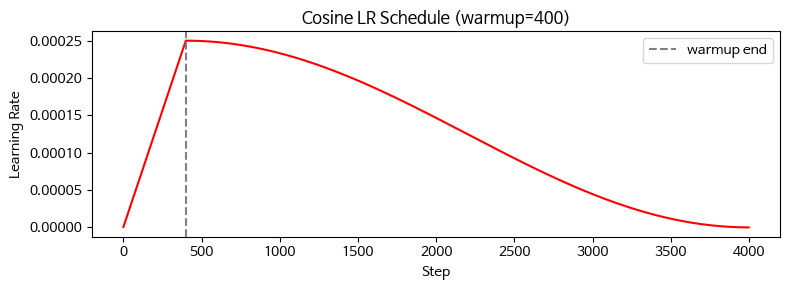

In [44]:
# LR 스케줄 시각화
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=400)
lrs = [test_schedule.step() for _ in range(4000)]
 
plt.figure(figsize=(8, 3))
plt.plot(lrs, 'r-', linewidth=1.5)
plt.axvline(400, color='gray', linestyle='--', label='warmup end')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Cosine LR Schedule (warmup=400)')
plt.legend()
plt.tight_layout()
plt.show()

### 5-2. 모델 학습

In [45]:
# 하이퍼파라미터
EPOCHS     = 10
BATCH_SIZE = 64
 
# DataLoader 구성: memmap 배열을 tensor로 변환
# np.memmap -> np.array 변환 후 tensor로 만들어야 메모리 매핑이 안전하게 동작
train_dataset = TensorDataset(
    torch.from_numpy(np.array(enc_tokens_mm)).long(),
    torch.from_numpy(np.array(segments_mm)).long(),
    torch.from_numpy(np.array(labels_nsp_mm)).long(),
    torch.from_numpy(np.array(labels_mlm_mm)).long(),
)
train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=(device.type == 'cuda')
)
 
train_steps  = len(train_dataloader) * EPOCHS
warmup_steps = max(100, train_steps // 10)
print(f"총 학습 step: {train_steps:,}  |  warmup: {warmup_steps:,}")
print(f"배치당 샘플: {BATCH_SIZE}  |  배치 수: {len(train_dataloader):,}")

총 학습 step: 46,880  |  warmup: 4,688
배치당 샘플: 64  |  배치 수: 4,688


In [46]:
# 옵티마이저 및 스케줄러
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4, betas=(0.9, 0.999), eps=1e-8)
lr_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=2.5e-4
)
 
# NSP loss: raw logit 2-class CrossEntropy
loss_fn_nsp = nn.CrossEntropyLoss()
 
# 결과 저장용 딕셔너리 생성
history = {
    'nsp_loss': [], 'mlm_loss': [],
    'nsp_acc' : [], 'mlm_acc' : []
}
 
save_dir = './pretrain_results'
os.makedirs(save_dir, exist_ok=True)

In [47]:
%%time

# 학습 루프
set_seed(42)

for epoch in range(EPOCHS):
    pre_train_model.train()
 
    epoch_nsp_loss = 0.0
    epoch_mlm_loss = 0.0
    epoch_nsp_acc  = 0.0
    epoch_mlm_acc  = 0.0
 
    loop = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)
    for batch in loop:
        enc_tok, seg, lbl_nsp, lbl_mlm = [b.to(device) for b in batch]
 
        optimizer.zero_grad()
 
        # forward — raw logit 반환
        logits_nsp, logits_mlm = pre_train_model(enc_tok, seg)
 
        # NSP loss: CrossEntropy(raw_logit, long_label)
        loss_nsp = loss_fn_nsp(logits_nsp, lbl_nsp)
        # MLM loss: 마스킹 위치만 계산, 20배 가중
        loss_mlm = lm_loss(lbl_mlm, logits_mlm)
 
        loss = loss_nsp + loss_mlm
        loss.backward()
 
        # gradient clipping으로 학습 안정화
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), max_norm=1.0)
 
        optimizer.step()
        lr_scheduler.step()  # step마다 LR 업데이트
 
        # 배치 단위 accuracy 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == lbl_nsp).float().mean().item()
        mlm_acc = lm_acc(lbl_mlm, logits_mlm).item()
 
        epoch_nsp_loss += loss_nsp.item()
        epoch_mlm_loss += loss_mlm.item()
        epoch_nsp_acc  += nsp_acc
        epoch_mlm_acc  += mlm_acc
 
        loop.set_postfix(
            nsp_l=f"{loss_nsp.item():.3f}",
            mlm_l=f"{loss_mlm.item():.3f}",
            nsp_a=f"{nsp_acc:.3f}",
            mlm_a=f"{mlm_acc:.3f}"
        )
 
    # epoch 평균값 기록
    n_batches = len(train_dataloader)
    e_nsp_loss = epoch_nsp_loss / n_batches
    e_mlm_loss = epoch_mlm_loss / n_batches
    e_nsp_acc  = epoch_nsp_acc  / n_batches
    e_mlm_acc  = epoch_mlm_acc  / n_batches
 
    history['nsp_loss'].append(e_nsp_loss)
    history['mlm_loss'].append(e_mlm_loss)
    history['nsp_acc'].append(e_nsp_acc)
    history['mlm_acc'].append(e_mlm_acc)
 
    print(f"[Epoch {epoch+1:02d}/{EPOCHS}]"
          f"  NSP loss: {e_nsp_loss:.4f}  MLM loss: {e_mlm_loss:.4f}"
          f"  NSP acc: {e_nsp_acc:.4f}  MLM acc: {e_mlm_acc:.4f}")
 
    # 체크포인트 저장
    torch.save(
        pre_train_model.state_dict(),
        os.path.join(save_dir, f'bert_pretrain_epoch_{epoch+1:02d}.pt')
    )
 
print("\n학습 완료")

Epoch 1/10:   0%|          | 0/4688 [00:00<?, ?it/s]

[Epoch 01/10]  NSP loss: 0.6113  MLM loss: 152.1850  NSP acc: 0.6109  MLM acc: 0.0277


Epoch 2/10:   0%|          | 0/4688 [00:00<?, ?it/s]

[Epoch 02/10]  NSP loss: 0.5607  MLM loss: 143.7966  NSP acc: 0.6290  MLM acc: 0.0423


Epoch 3/10:   0%|          | 0/4688 [00:00<?, ?it/s]

...

[Epoch 08/10]  NSP loss: 0.5250  MLM loss: 102.8332  NSP acc: 0.6607  MLM acc: 0.1898


Epoch 9/10:   0%|          | 0/4688 [00:00<?, ?it/s]

[Epoch 09/10]  NSP loss: 0.5239  MLM loss: 102.1076  NSP acc: 0.6625  MLM acc: 0.1923


Epoch 10/10:   0%|          | 0/4688 [00:00<?, ?it/s]

[Epoch 10/10]  NSP loss: 0.5228  MLM loss: 101.8326  NSP acc: 0.6639  MLM acc: 0.1933

학습 완료
CPU times: user 35min 11s, sys: 1min 16s, total: 36min 28s
Wall time: 34min 56s


에폭 8~10에서 NSP, MLM 모두 loss, acc상 변화가 크게 없다. 그 이전 에폭인 7부터 모델 용량의 한계에 도달한 것으로 보이며, **추가 학습을 진행해도 크게 개선되는 점이 없으리라 예상**한다.

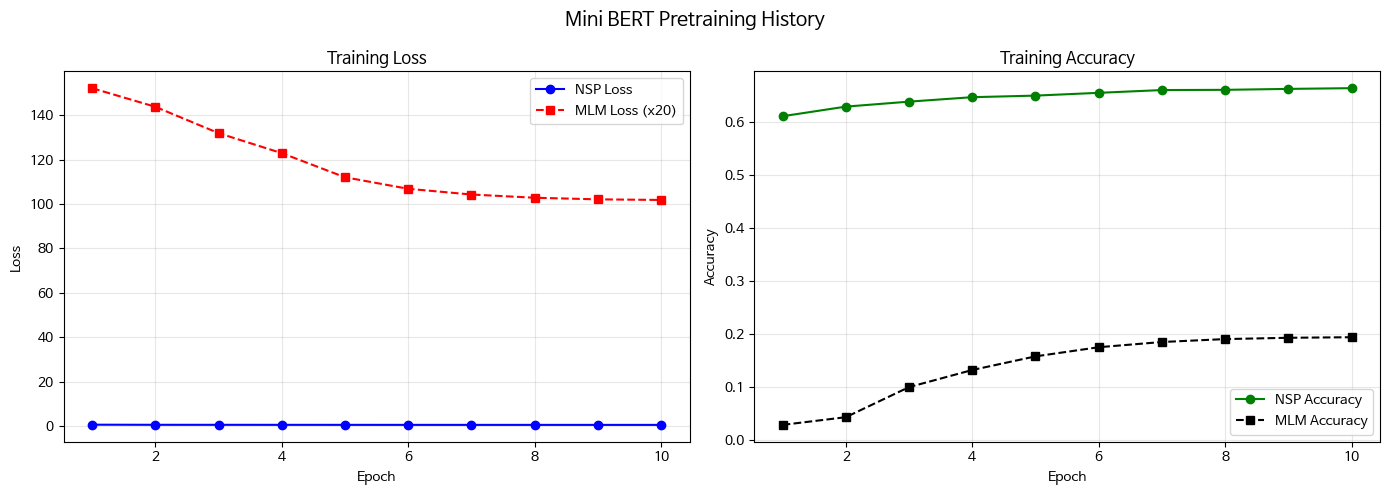


최종 결과:
  NSP Loss : 0.5228  → 0.6113 에서 변화
  MLM Loss : 101.8326  → 152.1850 에서 변화
  NSP Acc  : 0.6639
  MLM Acc  : 0.1933


In [48]:
# 학습 결과 시각화
epochs_range = range(1, EPOCHS + 1)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mini BERT Pretraining History', fontsize=14)
 
# Loss
axes[0].plot(epochs_range, history['nsp_loss'], 'b-o', label='NSP Loss')
axes[0].plot(epochs_range, history['mlm_loss'], 'r--s', label='MLM Loss (x20)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
# Accuracy
axes[1].plot(epochs_range, history['nsp_acc'], 'g-o', label='NSP Accuracy')
axes[1].plot(epochs_range, history['mlm_acc'], 'k--s', label='MLM Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'training_history.png'), dpi=120, bbox_inches='tight')
plt.show()
 
print("\n최종 결과:")
print(f"  NSP Loss : {history['nsp_loss'][-1]:.4f}  → {history['nsp_loss'][0]:.4f} 에서 변화")
print(f"  MLM Loss : {history['mlm_loss'][-1]:.4f}  → {history['mlm_loss'][0]:.4f} 에서 변화")
print(f"  NSP Acc  : {history['nsp_acc'][-1]:.4f}")
print(f"  MLM Acc  : {history['mlm_acc'][-1]:.4f}")

**NSP**

- loss: 초반의 `0.611`에서 10에폭 학습 후 `0.523`까지 꾸준히 감소했다.

- acc: `61.1`%로 시작해 `66.4`%까지 상승했다.

**MLM**

- loss: `152.2`에서 시작해 10 에폭 학습 후 `101.8`까지 하락했다. loss 설계를 MLM에 20배 가중치를 주도록 설계했기 때문에 NSP와 비교해 범위 차이가 난다.

- acc: `2.8`%에서 `19.3`%까지 향상되었다. MLM의 random baseline은 $1/8000 = 0.01%$로 (vocab_size=8000 중 하나를 맞춰야 함), 19.3%는 이를 상회하는 결과다.

## 6. 모델 평가

저장된 사전학습 BERT 모델을 불러와 아래 3가지 방식으로 평가를 진행한다.

- Mask 테스트

- NSP 테스트

- 임베딩 유사도 테스트

In [31]:
# 저장된 모델 불러오기
save_dir = './pretrain_results' # 저장 경로
load_epoch = 10  # 불러올 epoch 번호

pre_train_model = build_model_pre_train(config)
pre_train_model.load_state_dict(
    torch.load(
        os.path.join(save_dir, f'bert_pretrain_epoch_{load_epoch:02d}.pt'),
        map_location=device
    )
)
pre_train_model.to(device)
pre_train_model.eval()

print(f"epoch {load_epoch} 모델 로드 완료")

epoch 10 모델 로드 완료


### 6-1. Mask 테스트

문장에 [MASK]를 직접 넣고 모델이 어떤 예측값을 출력하는지 확인한다.

In [32]:
def predict_mask(model, vocab, sentence, n_seq, device, top_k=5):
    """
    [MASK] 위치의 상위 k개 예측 토큰을 출력
    - sentence에 [MASK]를 직접 넣어서 사용
    - 예: "서울은 대한민국의 [MASK]이다"
    """
    model.eval()

    # [MASK] 위치를 보존하면서 토크나이징
    # 문장을 [MASK] 기준으로 분리 → 각 부분을 따로 토크나이징 → 다시 합침
    parts = sentence.split("[MASK]")
    pieces = ["[CLS]"]
    mask_positions = []
    for i, part in enumerate(parts):
        pieces += vocab.encode_as_pieces(part)
        if i < len(parts) - 1:  # 마지막 part 뒤에는 [MASK] 없음
            mask_positions.append(len(pieces))
            pieces.append("[MASK]")
    pieces += ["[SEP]"]

    if not mask_positions:
        print("문장에 [MASK]가 없음")
        return

    # ID 변환 + 패딩
    ids = [vocab.piece_to_id(p) for p in pieces]
    ids += [0] * (n_seq - len(ids))
    segment = [0] * n_seq

    enc_tokens = torch.tensor([ids],     dtype=torch.long).to(device)
    segments   = torch.tensor([segment], dtype=torch.long).to(device)

    with torch.no_grad():
        _, logits_mlm = model.bert(enc_tokens, segments) # (1, n_seq, n_vocab)

    print(f"입력: {' '.join(pieces)}")
    print()

    for pos in mask_positions:
        topk_vals, topk_ids = torch.topk(logits_mlm[0, pos], k=top_k)
        topk_probs = torch.softmax(topk_vals, dim=-1)
        print(f"[MASK] 위치 {pos} 예측 top-{top_k}:")
        for rank, (token_id, prob) in enumerate(zip(topk_ids, topk_probs), 1):
            token = vocab.id_to_piece(token_id.item())
            print(f"  {rank}. {token:15s} ({prob.item()*100:.1f}%)")
        print()

In [33]:
# 테스트 문장들
test_sentences = [
    "서울은 대한민국의 [MASK]이다",
    "그는 학교에 [MASK]를 타고 갔다",
    "오늘 날씨가 [MASK]서 기분이 좋다",
    "인공지능 공부는 [MASK]다.",
    "적게 먹는 것은 [MASK]를 촉진한다."
]

for sent in test_sentences:
    predict_mask(pre_train_model, vocab, sent, n_seq, device, top_k=5)
    print("=" * 40)

입력: [CLS] ▁서울 은 ▁대한민국의 [MASK] ▁이 다 [SEP]

[MASK] 위치 4 예측 top-5:
  1. ▁대한민국의          (59.0%)
  2. ▁배우이다           (13.3%)
  3. ▁고등학교           (11.7%)
  4. ▁일본의            (11.0%)
  5. ▁사람을            (5.0%)

입력: [CLS] ▁그는 ▁학교 에 [MASK] ▁ 를 ▁타 고 ▁ 갔다 [SEP]

[MASK] 위치 4 예측 top-5:
  1. ▁있는             (23.8%)
  2. ▁같은             (23.7%)
  3. ▁대한             (21.8%)
  4. ▁한              (16.8%)
  5. ▁대해             (13.9%)

입력: [CLS] ▁오늘 ▁날 씨 가 [MASK] ▁서 ▁기 분 이 ▁좋 다 [SEP]

[MASK] 위치 5 예측 top-5:
  1. ▁다음             (51.7%)
  2. ▁같은             (22.3%)
  3. ▁작은             (10.4%)
  4. ▁있는             (7.9%)
  5. ▁날              (7.6%)

입력: [CLS] ▁인 공 지 능 ▁공 부는 [MASK] ▁다 . [SEP]

[MASK] 위치 7 예측 top-5:
  1. ▁다음과            (84.4%)
  2. ▁뜻이             (5.6%)
  3. ▁사람을            (3.8%)
  4. ▁같이             (3.5%)
  5. ▁다음을            (2.7%)

입력: [CLS] ▁적 게 ▁먹 는 ▁것은 [MASK] ▁ 를 ▁촉 진 한다 . [SEP]

[MASK] 위치 6 예측 top-5:
  1. ▁다른             (35.6%)
  2. ▁사람의            (23.4%)
  3. ▁다음           

**평가 결과 해석**
- vocab_size=8000이 작아 자주 쓰이는 어절도 서브워드로 분리되었다 (예: `▁날씨가` → `▁날 씨 가`).

- 5개 문장 모두 정답 토큰을 맞히지 못했으며, 문맥에 어울리는 토큰보다는 `▁다음`, `▁같은` 등 출현 빈도가 높은 일반적인 토큰을 선호하는 경향이 있다.

- 정확한 정답 토큰을 맞히려면 파라미터 수 확대 또는 학습 데이터 증가가 필요함을 알 수 있다.

### 6-2. NSP 테스트

두 문장의 연결이 자연스러운지 아닌지 모델이 잘 판단하는지 확인한다.

In [51]:
def predict_nsp(model, vocab, sent_a, sent_b, n_seq, device):
    """
    두 문장이 이어지는지(is_next=1) 아닌지(is_next=0) 예측
    """
    model.eval()

    tokens = (["[CLS]"] + vocab.encode_as_pieces(sent_a)
              + ["[SEP]"] + vocab.encode_as_pieces(sent_b) + ["[SEP]"])
    segment = ([0] * (len(vocab.encode_as_pieces(sent_a)) + 2)
               + [1] * (len(vocab.encode_as_pieces(sent_b)) + 1))

    ids = [vocab.piece_to_id(p) for p in tokens]
    ids     += [0] * (n_seq - len(ids))
    segment += [0] * (n_seq - len(segment))

    enc_tokens = torch.tensor([ids],     dtype=torch.long).to(device)
    segments   = torch.tensor([segment], dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, _ = pre_train_model(enc_tokens, segments)
        probs = torch.softmax(logits_nsp, dim=-1)[0]

    print(f"문장 A: {sent_a}")
    print(f"문장 B: {sent_b}")
    print(f"  이어지는 문장일 확률  : {probs[1].item()*100:.1f}%")
    print(f"  이어지지 않을 확률    : {probs[0].item()*100:.1f}%")
    print(f"  예측                  : {'이어짐 ✓' if probs[1] > probs[0] else '이어지지 않음 ✗'}")
    print()

In [52]:
# 이어지는 쌍 (True)
predict_nsp(pre_train_model, vocab,
            "오늘 날씨가 매우 맑다",
            "하늘에 구름 한 점 없었다",
            n_seq, device)

# 이어지지 않는 쌍 (False)
predict_nsp(pre_train_model, vocab,
            "오늘 날씨가 매우 맑다",
            "주식 시장이 급락했다",
            n_seq, device)

문장 A: 오늘 날씨가 매우 맑다
문장 B: 하늘에 구름 한 점 없었다
  이어지는 문장일 확률  : 61.6%
  이어지지 않을 확률    : 38.4%
  예측                  : 이어짐 ✓

문장 A: 오늘 날씨가 매우 맑다
문장 B: 주식 시장이 급락했다
  이어지는 문장일 확률  : 64.6%
  이어지지 않을 확률    : 35.4%
  예측                  : 이어짐 ✓



**평가 결과 해석**

- 이어지는 쌍(날씨 -> 구름)은 `61.6`%로 정확히 예측했으나, 무관한 쌍(날씨 -> 주식)도 `64.6`%로 이어진다고 잘못 예측했다.

- 두 쌍의 확률 차이가 단 3%에 불과해 모델이 두 문장의 의미적 연관성을 실질적으로 구분하지 못하는 것으로 보인다.

- 모델이 문맥 이해보다 특정 패턴에 편향되어 있을 가능성이 높다.

### 6-3. 임베딩 유사도 테스트

의미적으로 가까운 단어끼리 코사인 유사도가 높은지 확인한다.

In [53]:
def get_token_embedding(model, vocab, word, n_seq, device):
    """단어 하나의 CLS 임베딩 추출"""
    model.eval()
    tokens  = ["[CLS]"] + vocab.encode_as_pieces(word) + ["[SEP]"]
    ids     = [vocab.piece_to_id(p) for p in tokens]
    ids    += [0] * (n_seq - len(ids))
    segment = [0] * n_seq

    enc_tokens = torch.tensor([ids],     dtype=torch.long).to(device)
    segments   = torch.tensor([segment], dtype=torch.long).to(device)

    with torch.no_grad():
        logits_cls, _ = model.bert(enc_tokens, segments)
    return logits_cls[0]  # (d_model,)

In [54]:
# 유사해야 하는 쌍 vs 달라야 하는 쌍
pairs = [
    ("서울",   "부산",   "도시끼리"),
    ("서울",   "한국",   "연관 있음"),
    ("사과",   "바나나", "과일끼리"),
    ("서울",   "사과",   "무관"),
    ("강아지", "고양이", "동물끼리"),
    ("강아지", "자동차", "무관"),
]

print(f"{'단어A':^8} {'단어B':^8} {'관계':^12} {'유사도':^8}")
print("-" * 42)
for word_a, word_b, rel in pairs:
    emb_a = get_token_embedding(pre_train_model, vocab, word_a, n_seq, device)
    emb_b = get_token_embedding(pre_train_model, vocab, word_b, n_seq, device)
    sim   = cosine_similarity(emb_a.unsqueeze(0), emb_b.unsqueeze(0)).item()
    print(f"{word_a:^8} {word_b:^8} {rel:^12} {sim:^8.3f}")

  단어A      단어B         관계        유사도   
------------------------------------------
   서울       부산        도시끼리      0.962  
   서울       한국       연관 있음      0.944  
   사과      바나나        과일끼리      0.909  
   서울       사과         무관       0.823  
  강아지      고양이        동물끼리      0.940  
  강아지      자동차         무관       0.824  


**평가 결과 해석**

- 도시끼리(0.962), 동물끼리(0.940), 과일끼리(0.909) 등 같은 카테고리 내 단어쌍이 높은 유사도를 보였다.

- 무관한 쌍(서울 <-> 사과, 강아지 <-> 자동차)의 유사도가 0.82~0.83으로, 연관 있는 쌍과의 차이가 0.08 - 0.14에 불과해 변별력이 낮다.

- 전반적으로 유사도가 0.82 - 0.96의 좁은 범위에 몰려 있어 모델이 모든 단어쌍을 유사하게 표현하는 경향이 있다.

## 회고

- 모델을 평가하기 위해선 헤드를 교체해 분류 등 다른 과제에서의 성능을 확인해보는 방법 뿐이라고 믿었다. 프로젝트를 직접 해보니 이는 너무 성급한 생각임을 체감할 수 있었는데, 그 이유는 <6. 모델 평가> 단계에서 모델이 기본적인 '말'도 잘 하지 못하는 모습을 목격했기 때문이다.

- 예제 코드를 통해 정확도를 측정하고자 하는 대상과 범위, 예를 들어 전체 문장 또는 MASK된 단어인지에 따라 수치가 크게 달라짐을 눈으로 보았다. 손실이나 정확도 지표 설계를 어떻게 하면 정밀도와 정확성 있게 할 수 있을지 고민이 필요한 부분이다.

- 학습 곡선 시각화에서 디테일을 더 고려했어야 했다. MLM과 NSP loss 스케일 차이 때문에 NSP 곡선이 납작하게 나오는데, 두 그래프를 분리해서 MLM 따로, NSP 따로 그리거나 아니면 MLM loss를 다시 나누어 그림으로써 학습 상태를 더 잘 보이게 했어야 했다.

- 프로젝트를 다 하고 나니 에폭별 모델 10개와 원본 데이터셋 저장, 인스턴스 생성으로 인해 디스크 메모리가 5% 이상 더 소모되었다. 실무에서는 어떤 기준으로 관리를 하는지 궁금해서 한번 알아봐야겠다.